In [44]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import json
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

ALPHA = 0.001
EPSILON = 0.03
MAXITERS = 300
ATTACK_PCTS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
K_RANKS = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]

# Select which attack to run
ATTACK_METHOD = "deepfool"  # Change to "pgd" or other methods

# DATA_DIR = Path('spambase_50_50')
DATA_DIR = Path('/home/skada009/aro/spambase_10_40_50')
SCORES_DIR = Path('/home/skada009/aro/experiments/noise_scoring_outputs/20260324_203954')
if ATTACK_METHOD == "pgd" or ATTACK_METHOD == "fgsm":
    OUTPUT_DIR = Path(f'targeted_vaccination_results_10_40_50_{ATTACK_METHOD}_{EPSILON}')
elif ATTACK_METHOD == "deepfool":
    OUTPUT_DIR = Path(f'targeted_vaccination_results_10_40_50_{ATTACK_METHOD}_{ALPHA}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



Device: cuda
GPU: NVIDIA RTX A6000


In [45]:
data = np.load(DATA_DIR / 'train_test_data.npz')
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test']
n_test, n_features = X_test.shape

prep = np.load(DATA_DIR / 'preprocessing.npz')
weights = prep['weights']
bounds = [prep['bounds_min'], prep['bounds_max']]


class SpambaseNet(nn.Module):
    def __init__(self, D_in):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)


checkpoint = torch.load(DATA_DIR / 'spambase_mlp.pth', map_location=device)
model = SpambaseNet(D_in=57).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
X_test_t = torch.FloatTensor(X_test).to(device)
with torch.no_grad():
    test_preds = model(X_test_t).argmax(dim=1).cpu().numpy()
correct_mask = (test_preds == y_test)
correct_indices = np.where(correct_mask)[0]
n_correct = len(correct_indices)

print(f'Test set: {n_test} samples, {n_features} features')
print(f'Correctly classified: {n_correct}/{n_test} ({n_correct/n_test:.2%})')

print(f"✓ Model loaded | Train Acc: {checkpoint.get('train_accuracy', 'N/A')}, Test Acc: {checkpoint.get('test_accuracy', 'N/A')}")

print("Loading test data...")
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test'].astype(np.int64)
print(f"✓ Test set: {X_test.shape}")

print("Loading preprocessing parameters...")
weights = prep['weights'].astype(np.float32)
bounds_min = prep['bounds_min'].astype(np.float32)
bounds_max = prep['bounds_max'].astype(np.float32)
bounds = [bounds_min, bounds_max]
print(f"✓ Bounds: [{bounds_min.min():.4f}, {bounds_max.max():.4f}], Weights shape: {weights.shape}")


Test set: 2301 samples, 57 features
Correctly classified: 2058/2301 (89.44%)
✓ Model loaded | Train Acc: 0.9097826086956522, Test Acc: 0.894393741851369
Loading test data...
✓ Test set: (2301, 57)
Loading preprocessing parameters...
✓ Bounds: [0.0000, 1.0000], Weights shape: (57,)


In [46]:
from turtle import home


score1_removal_order = np.load(f'{SCORES_DIR}/test_clean_data_score1_removed_index.npy').astype(int)
score2_value = np.load(f'{SCORES_DIR}/test_clean_data_score2_noise_scores.npy')

# Noisiest-first orderings, filtered to correctly-classified only
score1_order = [idx for idx in score1_removal_order if correct_mask[idx]]
score2_order = [idx for idx in np.argsort(score2_value)[::-1] if correct_mask[idx]]

score_orders = {'Score 1': score1_order, 'Score 2': score2_order}
print(f'Eligible points per score ordering: {len(score1_order)}')

Eligible points per score ordering: 2057


In [47]:
# Import attack methods
from utils.fgsm import create_fgsm, fgsm_attack

# Create attack instance
if ATTACK_METHOD == "fgsm":
    wrapped_model, attack_obj = create_fgsm(model, bounds_min, bounds_max, eps=EPSILON)
    attack_func = fgsm_attack
    
elif ATTACK_METHOD == "pgd":
    from utils.pgd_attack import create_pgd, pgd_attack
    wrapped_model, attack_obj = create_pgd(model, bounds_min, bounds_max, eps=EPSILON)
    attack_func = pgd_attack

elif ATTACK_METHOD == "deepfool":
    from utils.deepfool import deepfool
    wrapped_model, attack_obj = None, None
    print(ALPHA)
    def deepfool_attack(x_sample, model, _attack_obj, device):
        # deepfool expects a torch Tensor sample
        x_t = torch.FloatTensor(x_sample).to(device)
        y_orig, y_adv, x_adv, _ = deepfool(
            x_t, model,
            maxiters=MAXITERS, alpha=ALPHA,
            bounds=bounds, weights=[],
        )
        return int(y_orig), int(y_adv), x_adv

    attack_func = deepfool_attack

else:
    raise ValueError(f"Unknown ATTACK_METHOD={ATTACK_METHOD!r}")

print(f"✓ Attack method: {ATTACK_METHOD.upper()}")


0.001
✓ Attack method: DEEPFOOL


In [48]:
print(f'\n{"="*50}')
print(f"GENERATING ADVERSARIAL SAMPLES ({ATTACK_METHOD})")
print(f'{"="*50}')

X_adv = np.copy(X_test)
attack_success = np.zeros(n_test, dtype=int)
t0 = time.time()

for i, idx in enumerate(correct_indices):
    x = torch.FloatTensor(X_test[idx]).to(device)
    y_orig_i, y_adv_i, x_adv_i = attack_func(X_test[idx], model, attack_obj, device)
    
    X_adv[idx] = x_adv_i
    attack_success[idx] = 1 if y_orig_i != y_adv_i else 0

    if (i + 1) % 200 == 0 or i == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (n_correct - i - 1)
        n_succ = attack_success[correct_indices[:i+1]].sum()
        print(f'  [{i+1:>4d}/{n_correct}] success so far: {n_succ}/{i+1} | ETA: {eta:.0f}s')

n_succ = attack_success[correct_indices].sum()
print(f'  Done: {n_succ}/{n_correct} ({n_succ/n_correct:.2%}) | {time.time()-t0:.1f}s')

np.savez_compressed(
    OUTPUT_DIR / 'adversarial_samples.npz',
    **{f'X_adv_{ATTACK_METHOD}': X_adv, f'success_{ATTACK_METHOD}': attack_success}
)
print('\nAdversarial samples saved to', OUTPUT_DIR / 'adversarial_samples.npz')


GENERATING ADVERSARIAL SAMPLES (deepfool)
  [   1/2058] success so far: 1/1 | ETA: 376s
  [ 200/2058] success so far: 191/200 | ETA: 619s
  [ 400/2058] success so far: 380/400 | ETA: 565s
  [ 600/2058] success so far: 570/600 | ETA: 492s
  [ 800/2058] success so far: 758/800 | ETA: 429s
  [1000/2058] success so far: 944/1000 | ETA: 367s
  [1200/2058] success so far: 1131/1200 | ETA: 299s
  [1400/2058] success so far: 1313/1400 | ETA: 231s
  [1600/2058] success so far: 1505/1600 | ETA: 161s
  [1800/2058] success so far: 1690/1800 | ETA: 91s
  [2000/2058] success so far: 1881/2000 | ETA: 20s
  Done: 1936/2058 (94.07%) | 723.1s

Adversarial samples saved to targeted_vaccination_results_10_40_50_deepfool_0.001/adversarial_samples.npz


In [1]:
print(f'\n{"="*50}')
print(f'  ASR Check Before Vaccination')
print(f'{"="*50}')
n_succ = attack_success[correct_indices].sum()
print(f'DeepFool: {n_succ}/{n_correct} ({n_succ/n_correct:.2%}) attacks succeeded')


  ASR Check Before Vaccination


NameError: name 'attack_success' is not defined

In [49]:
def vaccinate_and_classify(X_mixed, k, model, device):
    """Apply k-rank SVD approximation, clip to [0,1], classify with model."""
    U, S, Vt = np.linalg.svd(X_mixed, full_matrices=False)
    X_vacc = (U[:, :k] * S[:k]) @ Vt[:k, :]
    X_vacc = np.clip(X_vacc, 0, 1).astype(np.float32)
    with torch.no_grad():
        preds = model(torch.FloatTensor(X_vacc).to(device)).argmax(dim=1).cpu().numpy()
    return preds


rows = []
t_total = time.time()

for score_name, order in score_orders.items():
    n_eligible = len(order)
    for attack_pct in ATTACK_PCTS:
        n_attack = max(1, int(n_eligible * attack_pct / 100))

        # Noisy tier: first n_attack in noisiest-first order
        noisy_indices = order[:n_attack]
        # Structural tier: last n_attack in noisiest-first order (most structural)
        structural_indices = order[-n_attack:]

        for tier_name, tier_idx in [('structural', structural_indices), ('noisy', noisy_indices)]:
            # Construct mixed matrix: replace targeted tier with adversarial versions
            X_mixed = np.copy(X_test)
            n_successfully_attacked = 0
            for idx in tier_idx:
                if attack_success[idx]:
                    X_mixed[idx] = X_adv[idx]
                    n_successfully_attacked += 1

            # Calculate ASR before vaccination
            asr_before = n_successfully_attacked / len(tier_idx) if len(tier_idx) > 0 else 0.0

            if n_successfully_attacked == 0:
                for k in K_RANKS:
                    rows.append({
                        'score_type': score_name, 'tier': tier_name,
                        'attack_pct': attack_pct, 'k': k,
                        'n_targeted': len(tier_idx), 'n_attacked': 0,
                        'restoration_rate': 0.0, 'asr_after': 0.0,
                        'asr_before': asr_before,
                    })
                continue
            print(f'\n{score_name} | {tier_name} tier | attack_pct={attack_pct}% | targeted {len(tier_idx)}, successfully attacked {n_successfully_attacked}')
            print("ASR before vaccination: {:.2%}".format(asr_before))
            # Single SVD, then evaluate at each k
            U, S, Vt = np.linalg.svd(X_mixed, full_matrices=False)

            for k in K_RANKS:
                X_vacc = (U[:, :k] * S[:k]) @ Vt[:k, :]
                X_vacc = np.clip(X_vacc, 0, 1).astype(np.float32)
                with torch.no_grad():
                    preds = model(torch.FloatTensor(X_vacc).to(device)).argmax(dim=1).cpu().numpy()

                n_restored = sum(
                    1 for idx in tier_idx
                    if attack_success[idx] and preds[idx] == y_test[idx]
                )
                restoration_rate = n_restored / n_successfully_attacked

                rows.append({
                    'score_type': score_name, 'tier': tier_name,
                    'attack_pct': attack_pct, 'k': k,
                    'n_targeted': len(tier_idx), 'n_attacked': n_successfully_attacked,
                    'restoration_rate': restoration_rate, 'asr_after': 1 - restoration_rate,
                    'asr_before': asr_before,
                })

        print(f'{score_name} | attack_pct={attack_pct:>3d}% done ({time.time()-t_total:.1f}s)')

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_DIR / 'vaccination_sweep.csv', index=False)
print(f'\nSweep complete: {len(df)} rows, saved to {OUTPUT_DIR / "vaccination_sweep.csv"}')



Score 1 | structural tier | attack_pct=10% | targeted 205, successfully attacked 205
ASR before vaccination: 100.00%

Score 1 | noisy tier | attack_pct=10% | targeted 205, successfully attacked 132
ASR before vaccination: 64.39%
Score 1 | attack_pct= 10% done (0.5s)

Score 1 | structural tier | attack_pct=20% | targeted 411, successfully attacked 411
ASR before vaccination: 100.00%

Score 1 | noisy tier | attack_pct=20% | targeted 411, successfully attacked 307
ASR before vaccination: 74.70%
Score 1 | attack_pct= 20% done (1.5s)

Score 1 | structural tier | attack_pct=30% | targeted 617, successfully attacked 617
ASR before vaccination: 100.00%

Score 1 | noisy tier | attack_pct=30% | targeted 617, successfully attacked 495
ASR before vaccination: 80.23%
Score 1 | attack_pct= 30% done (2.5s)

Score 1 | structural tier | attack_pct=40% | targeted 822, successfully attacked 822
ASR before vaccination: 100.00%

Score 1 | noisy tier | attack_pct=40% | targeted 822, successfully attacked 7

Saved vaccination_score1_structural.png


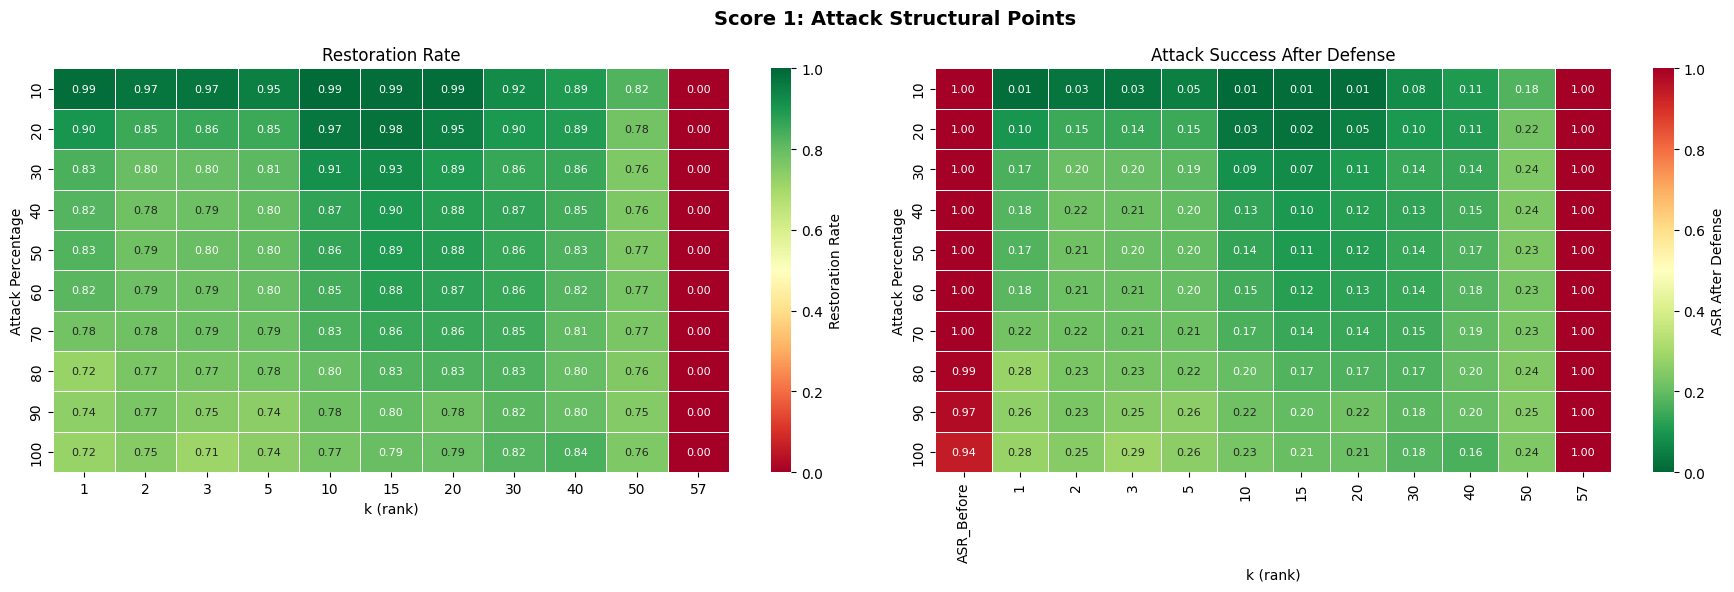

Saved vaccination_score1_noisy.png


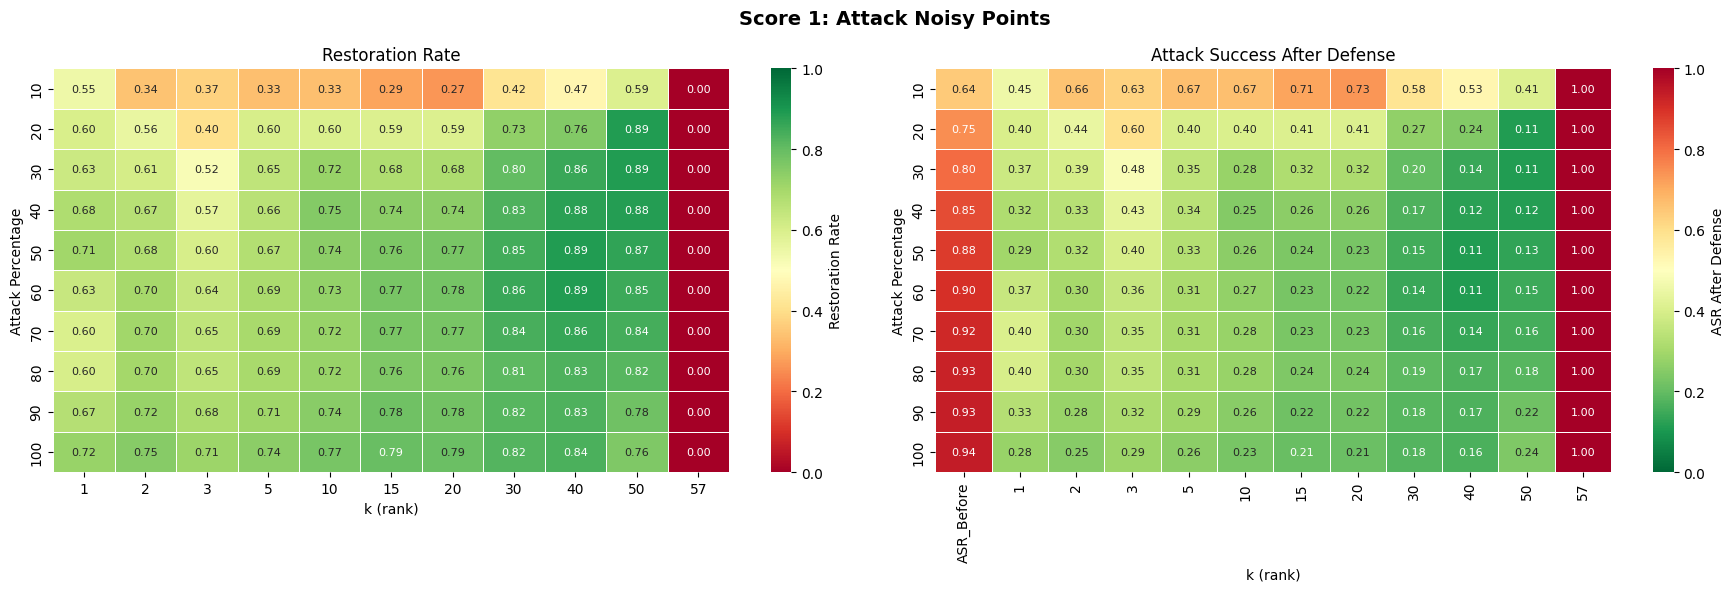

Saved vaccination_score2_structural.png


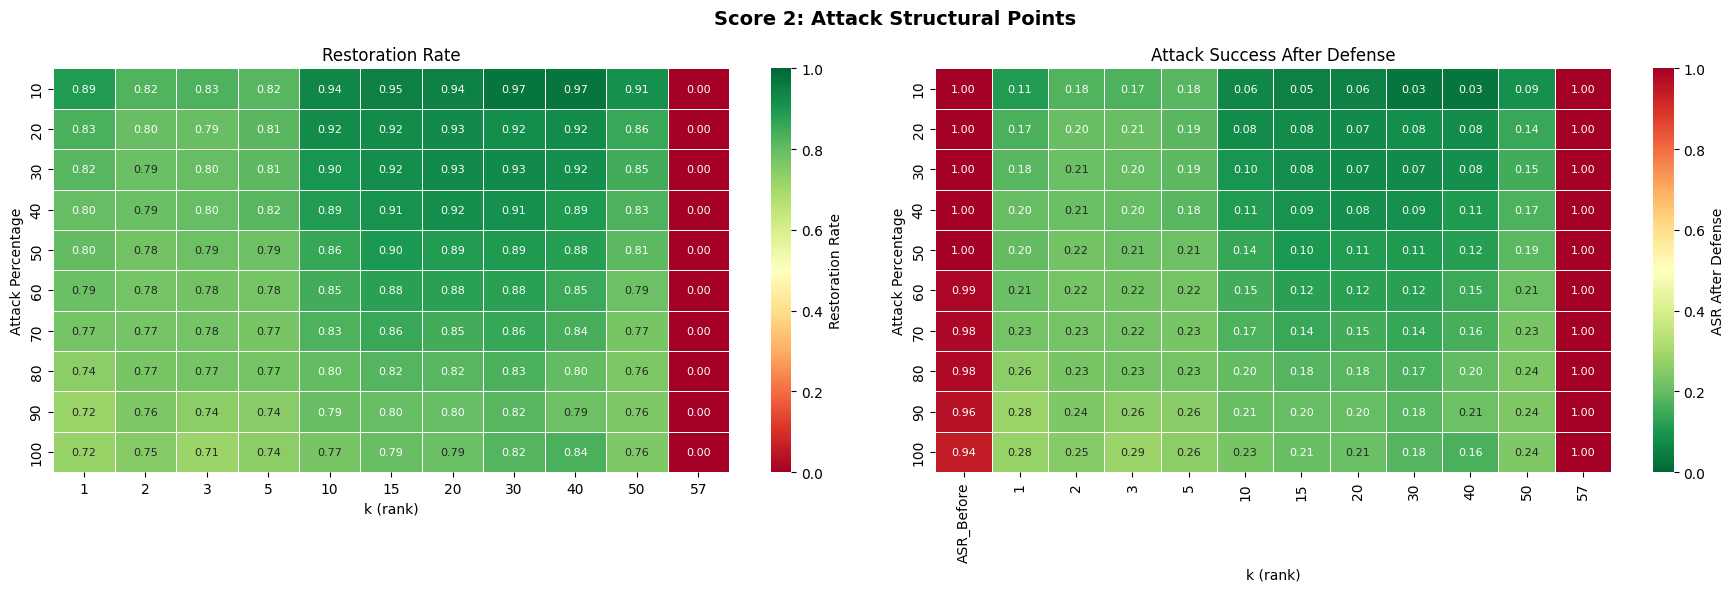

Saved vaccination_score2_noisy.png


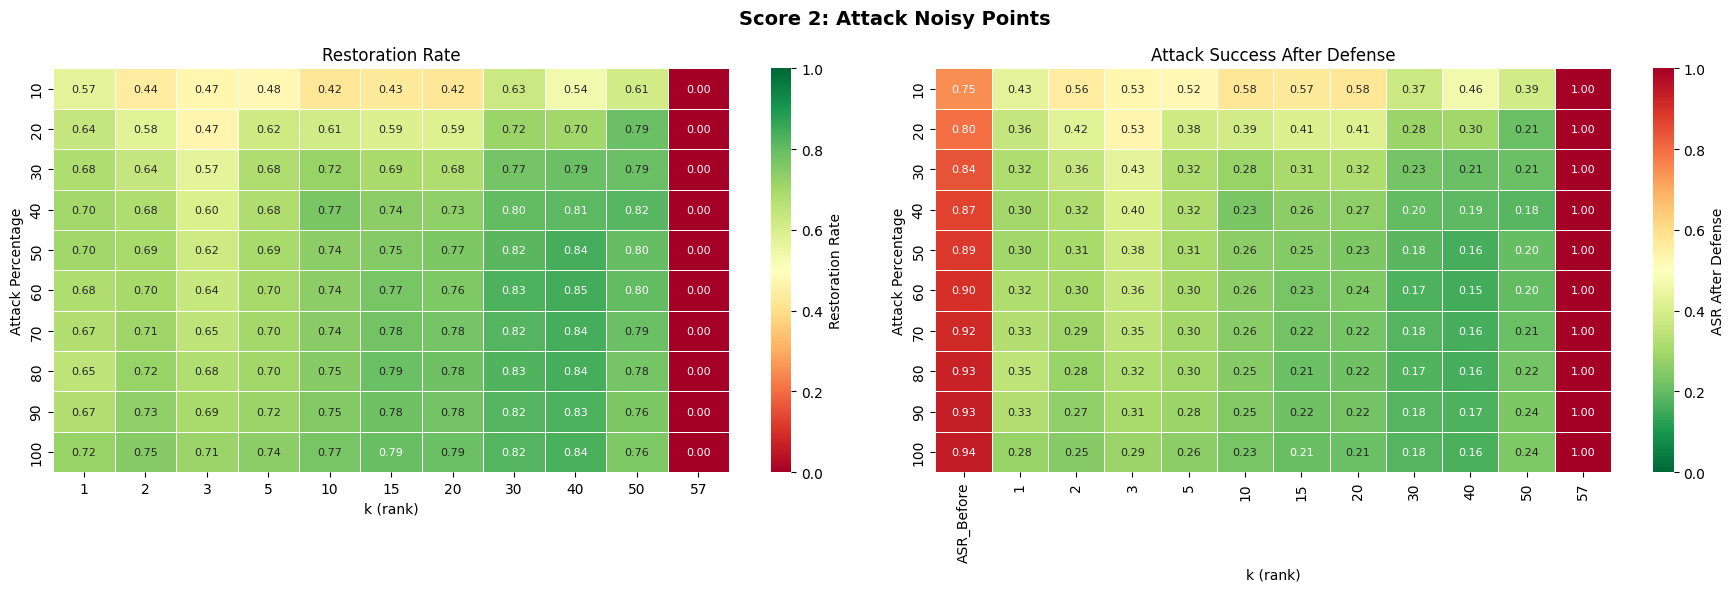

In [50]:
def plot_vaccination_heatmaps(df, score_name, tier_name, output_dir):
    """Produce heatmaps for restoration rate and ASR after defense."""
    sub = df[(df['score_type'] == score_name) & (df['tier'] == tier_name)]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Get ASR before vaccination (same for all k values within a score/tier combination)
    asr_before_values = sub.groupby('attack_pct')['asr_before'].first()
    
    fig.suptitle(f'{score_name}: Attack {tier_name.capitalize()} Points', fontsize=14, fontweight='bold')

    # Restoration rate heatmap with ASR before as first column
    pivot_restoration = sub.pivot(index='attack_pct', columns='k', values='restoration_rate')
    pivot_restoration = pivot_restoration.sort_index(ascending=True)
    
    # Add ASR before as a column at the beginning
    pivot_restoration_with_asr = pivot_restoration.copy()
    # pivot_restoration_with_asr.insert(0, 'ASR_Before', [asr_before_values[pct] for pct in pivot_restoration_with_asr.index])
    
    sns.heatmap(
        pivot_restoration_with_asr, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=0, vmax=1, linewidths=0.5, annot_kws={'size': 8}, cbar_kws={'label': 'Restoration Rate'}
    )
    axes[0].set_title('Restoration Rate')
    axes[0].set_xlabel('k (rank)')
    axes[0].set_ylabel('Attack Percentage')

    # Attack success after defense heatmap with ASR before as first column
    pivot_asr = sub.pivot(index='attack_pct', columns='k', values='asr_after')
    pivot_asr = pivot_asr.sort_index(ascending=True)
    
    # Add ASR before as a column at the beginning
    pivot_asr_with_asr = pivot_asr.copy()
    pivot_asr_with_asr.insert(0, 'ASR_Before', [asr_before_values[pct] for pct in pivot_asr_with_asr.index])
    
    sns.heatmap(
        pivot_asr_with_asr, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn_r',
        vmin=0, vmax=1, linewidths=0.5, annot_kws={'size': 8}, cbar_kws={'label': 'ASR After Defense'}
    )
    axes[1].set_title('Attack Success After Defense')
    axes[1].set_xlabel('k (rank)')
    axes[1].set_ylabel('Attack Percentage')

    plt.tight_layout()
    fname = f'vaccination_{score_name.lower().replace(" ", "")}_{tier_name}.png'
    fig.savefig(output_dir / fname, dpi=150, bbox_inches='tight')
    print(f'Saved {fname}')
    
    plt.show()


for score_name in score_orders:
    for tier_name in ['structural', 'noisy']:
        plot_vaccination_heatmaps(df, score_name, tier_name, OUTPUT_DIR)


In [51]:
summary = {
    'config': {
        'alpha': ALPHA, 'maxiters': MAXITERS,
        'attack_method': '{ATTACK_METHOD.upper()}',
        'attack_pcts': ATTACK_PCTS, 'k_ranks': K_RANKS,
        'n_test': int(n_test), 'n_correct': int(n_correct),
    },
    'attack_success': {
        '{ATTACK_METHOD.upper()}': int(attack_success[correct_indices].sum())
    },
}
with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All results saved to', OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {p.name:45s} ({p.stat().st_size/1024:.1f} KB)')

All results saved to targeted_vaccination_results_10_40_50_deepfool_0.001
  adversarial_samples.npz                       (285.7 KB)
  summary.json                                  (0.5 KB)
  vaccination_score1_noisy.png                  (240.4 KB)
  vaccination_score1_structural.png             (225.3 KB)
  vaccination_score2_noisy.png                  (239.1 KB)
  vaccination_score2_structural.png             (220.7 KB)
  vaccination_sweep.csv                         (35.2 KB)
